# Fitting a Bond Yield Curve

Fitting a bond yield curve using the range of parametric functions provided

In [1]:
import datetime as dt
import pandas as pd
import numpy as np

In [2]:
from financepy.utils import *
from financepy.products.bonds import *


### Load up some Bond Data

In [3]:
# Move into the local folder of notebook
%pwd
%cd notebooks/products/bonds/
%pwd


[WinError 3] The system cannot find the path specified: 'notebooks/products/bonds/'
C:\Users\Dominic\Dropbox\Desktop\RESEARCH_DB\FinancePy\Code\financepy-git\notebooks\products\bonds


'C:\\Users\\Dominic\\Dropbox\\Desktop\\RESEARCH_DB\\FinancePy\\Code\\financepy-git\\notebooks\\products\\bonds'

In [4]:
bond_dataframe = pd.read_csv('./data/giltbondprices.txt', sep='\t')

In [5]:
# CALCULATE MID MARKET PRICES
bond_dataframe['mid'] = 0.5*(bond_dataframe['bid'] + bond_dataframe['ask'])

In [6]:
# SPECIFY UK BOND CONVENTIONS
freq_type = FrequencyTypes.SEMI_ANNUAL
dc_type = DayCountTypes.ACT_ACT_ICMA
settlement = Date(19, 9, 2012)

In [7]:
bonds = []
ylds = []

# LOAD BONDS AND CREATE A VECTOR OF FINBOND AND THEIR CORRESPONDING YIELDS

for index, bondData in bond_dataframe.iterrows():

    date_string = bondData['maturity']
    mat_dt_time = dt.datetime.strptime(date_string, '%d-%b-%y')
    maturity_dt = from_datetime(mat_dt_time)
    coupon = bondData['coupon']/100.0
    clean_price = bondData['mid']
    issue_dt = Date(maturity_dt.d, maturity_dt.m, 2000)
    bond = Bond(issue_dt, maturity_dt, coupon, freq_type, dc_type)
    yld = bond.yield_to_maturity(settlement, clean_price)
    bonds.append(bond)
    ylds.append(yld)

## Fitting the Yield Curves

### Cubic Polynomial

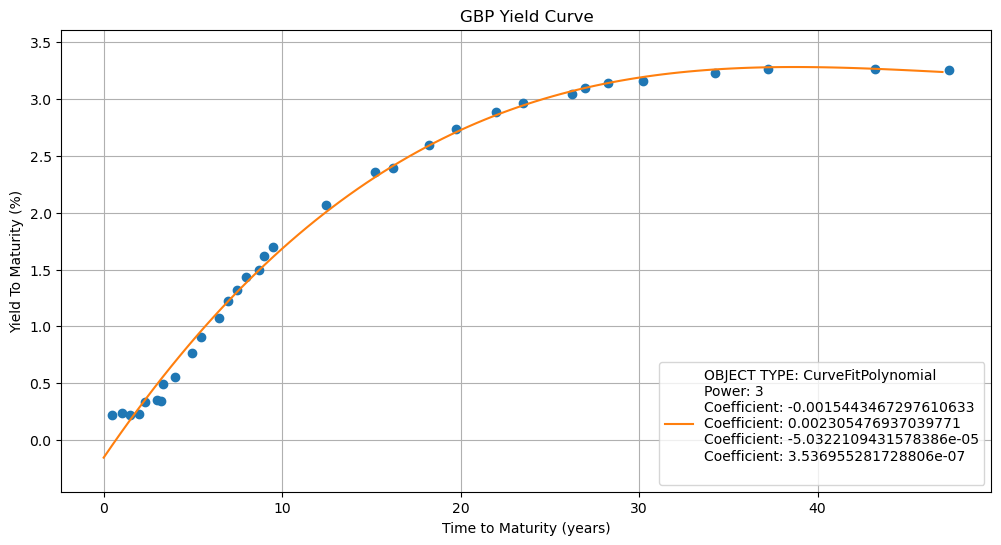

In [8]:
# FIT THE BOND YIELDS TO A CUBIC POLYNOMIAL
curve_fit_method = CurveFitPolynomial()
fitted_curve1 = BondFittedYieldCurve(settlement, bonds, ylds, curve_fit_method)
fitted_curve1.plot("GBP Yield Curve")

See the cubic coefficients

In [9]:
print(fitted_curve1.curve_fit)

OBJECT TYPE: CurveFitPolynomial
Power: 3
Coefficient: -0.0015443467297610633
Coefficient: 0.002305476937039771
Coefficient: -5.0322109431578386e-05
Coefficient: 3.536955281728806e-07



### Quintic Polynomial

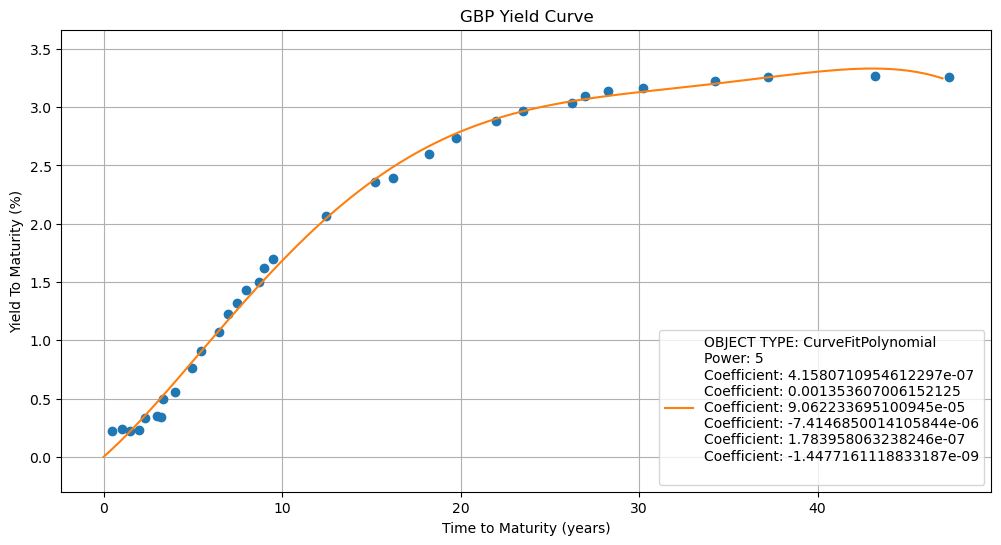

In [10]:
# FIT THE BOND YIELDS TO A QUINTIC POLYNOMIAL
curve_fit_method = CurveFitPolynomial(5)
fitted_curve2 = BondFittedYieldCurve(settlement, bonds, ylds, curve_fit_method)
fitted_curve2.plot("GBP Yield Curve")

See the quintic coefficients

In [11]:
print(fitted_curve2.curve_fit)

OBJECT TYPE: CurveFitPolynomial
Power: 5
Coefficient: 4.1580710954612297e-07
Coefficient: 0.001353607006152125
Coefficient: 9.062233695100945e-05
Coefficient: -7.4146850014105844e-06
Coefficient: 1.783958063238246e-07
Coefficient: -1.4477161118833187e-09



### Nelson-Siegel Curve

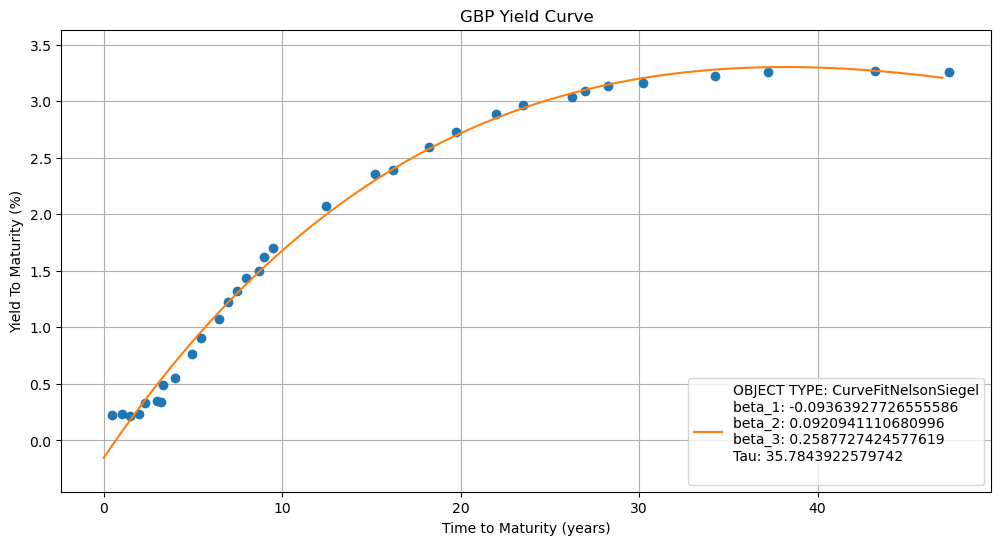

In [12]:
# FIT THE BONDS TO A NELSON-SIEGEL CURVE
curve_fit_method = CurveFitNelsonSiegel()
fitted_curve3 = BondFittedYieldCurve(settlement, bonds, ylds, curve_fit_method)
fitted_curve3.plot("GBP Yield Curve")

In [13]:
print(fitted_curve3.curve_fit)

OBJECT TYPE: CurveFitNelsonSiegel
beta_1: -0.09363927726555586
beta_2: 0.0920941110680996
beta_3: 0.2587727424577619
Tau: 35.7843922579742



### Nelson-Siegel Svensson Curve

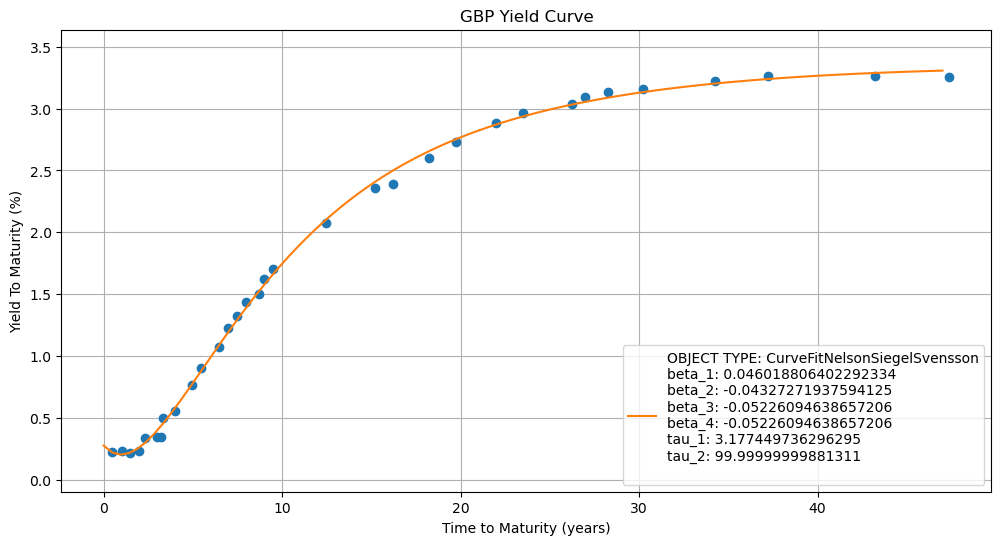

In [14]:
# FIT THE BONDS TO A NELSON-SIEGEL-SVENSSON CURVE
curve_fit_method = CurveFitNelsonSiegelSvensson()
fitted_curve4 = BondFittedYieldCurve(settlement, bonds, ylds, curve_fit_method)
fitted_curve4.plot("GBP Yield Curve")

In [15]:
print(fitted_curve4.curve_fit)

OBJECT TYPE: CurveFitNelsonSiegelSvensson
beta_1: 0.046018806402292334
beta_2: -0.04327271937594125
beta_3: -0.05226094638657206
beta_4: -0.05226094638657206
tau_1: 3.177449736296295
tau_2: 99.99999999881311



### B-Spline Curve

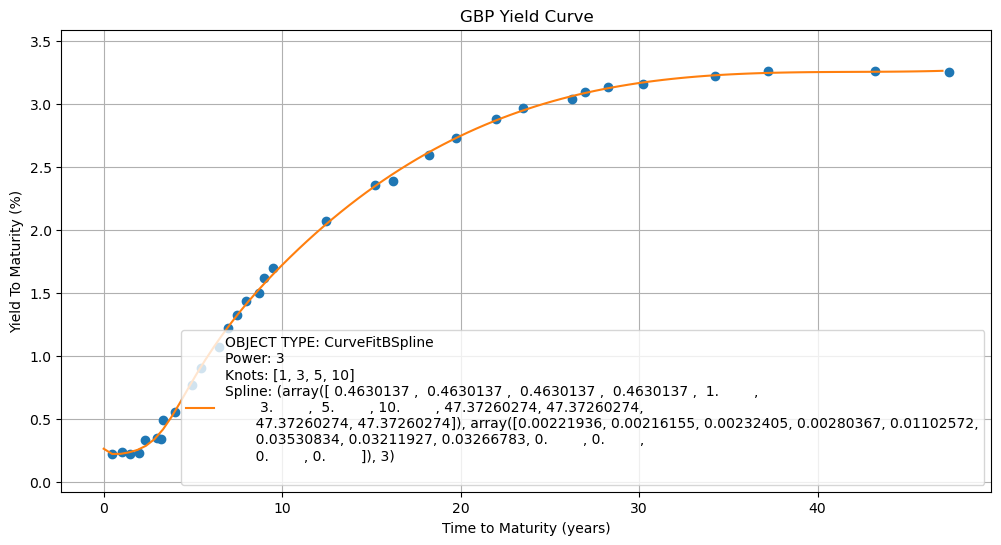

In [16]:
# FIT THE BONDS TO A B-SPLINE CURVE
curve_fit_method = CurveFitBSpline()
fitted_curve5 = BondFittedYieldCurve(settlement, bonds, ylds, curve_fit_method)
fitted_curve5.plot("GBP Yield Curve")

In [17]:
print(fitted_curve5.curve_fit)

OBJECT TYPE: CurveFitBSpline
Power: 3
Knots: [1, 3, 5, 10]
Spline: (array([ 0.4630137 ,  0.4630137 ,  0.4630137 ,  0.4630137 ,  1.        ,
        3.        ,  5.        , 10.        , 47.37260274, 47.37260274,
       47.37260274, 47.37260274]), array([0.00221936, 0.00216155, 0.00232405, 0.00280367, 0.01102572,
       0.03530834, 0.03211927, 0.03266783, 0.        , 0.        ,
       0.        , 0.        ]), 3)



## Accessing the Curve

You can access a yield from a date as follows

In [18]:
# EXTRACT A YIELD FROM A FITTED YIELD CURVE
maturity_dt = Date(19, 9, 2030)
interp_yield = fitted_curve5.interp_yield(maturity_dt)
print(maturity_dt, interp_yield*100)

19-SEP-2030 2.6018581947640538


## Vectorisations

You can also access the curve using a time and this can be vectorised.

In [19]:
times = np.linspace(0,10,100)

In [20]:
interp_yields = fitted_curve5.interp_yield(times)

In [21]:
interp_yields*100

array([0.26306396, 0.24887951, 0.23790459, 0.22978986, 0.22418599,
       0.22074367, 0.21911357, 0.21894635, 0.21989271, 0.22160331,
       0.2237289 , 0.22601017, 0.22845506, 0.23112095, 0.2340652 ,
       0.23734517, 0.24101824, 0.24514177, 0.24977313, 0.25496967,
       0.26078878, 0.2672878 , 0.27452412, 0.28255509, 0.29143808,
       0.30123046, 0.3119896 , 0.32377285, 0.33663759, 0.35064118,
       0.36584038, 0.38224459, 0.39978296, 0.41837688, 0.43794771,
       0.45841684, 0.47970564, 0.50173549, 0.52442777, 0.54770384,
       0.5714851 , 0.59569292, 0.62024867, 0.64507373, 0.67008948,
       0.6952173 , 0.72037856, 0.74549464, 0.77048691, 0.79527676,
       0.81978729, 0.84398152, 0.86786238, 0.89143451, 0.91470257,
       0.93767122, 0.96034512, 0.9827289 , 1.00482724, 1.02664479,
       1.0481862 , 1.06945612, 1.09045922, 1.11120014, 1.13168355,
       1.15191409, 1.17189643, 1.19163521, 1.21113509, 1.23040073,
       1.24943678, 1.2682479 , 1.28683874, 1.30521396, 1.32337

Copyright (c) 2020 Dominic O'Kane